In [12]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from pycocotools.coco import COCO
from PIL import Image

In [13]:
class AquariumDataset(Dataset):

    def __init__(self, root):
        self.root = root
        self.coco = COCO(os.path.join(root, "_annotations.coco.json"))
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, idx):

        img_id = self.ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        if len(anns) == 0:
            return self.__getitem__((idx + 1) % len(self.ids))

        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root, img_info["file_name"])

        img = Image.open(img_path).convert("RGB")
        w,h = img.size

        img = img.resize((640,640))
        img = F.to_tensor(img)

        sx = 640 / w
        sy = 640 / h

        boxes = []
        labels = []

        for ann in anns:
            x,y,bw,bh = ann["bbox"]

            x1 = x * sx
            y1 = y * sy
            x2 = (x + bw) * sx
            y2 = (y + bh) * sy

            boxes.append([x1,y1,x2,y2])
            labels.append(ann["category_id"] + 1)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        return img, {"boxes": boxes, "labels": labels}

    def __len__(self):
        return len(self.ids)

In [14]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = AquariumDataset("/kaggle/input/datasets/sahgopal/aquarium-detaset/train")

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [15]:
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")

num_classes = 8 + 1   # aquarium classes + background

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

model.to(device)

cuda


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block):

In [16]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [17]:
import gc

epochs = 20

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for imgs, targets in train_loader:

        imgs = [img.to(device) for img in imgs]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        del imgs, targets, loss_dict
        gc.collect()
        torch.cuda.empty_cache()

    print(f"Epoch {epoch+1} Loss: {total_loss:.3f}")

Epoch 1 Loss: 226.470
Epoch 2 Loss: 175.236
Epoch 3 Loss: 160.212
Epoch 4 Loss: 159.065
Epoch 5 Loss: 156.159
Epoch 6 Loss: 156.832
Epoch 7 Loss: 149.257
Epoch 8 Loss: 151.037
Epoch 9 Loss: 152.368
Epoch 10 Loss: 144.994
Epoch 11 Loss: 147.201
Epoch 12 Loss: 146.763
Epoch 13 Loss: 147.266
Epoch 14 Loss: 139.659
Epoch 15 Loss: 146.733
Epoch 16 Loss: 143.774
Epoch 17 Loss: 136.295
Epoch 18 Loss: 139.751
Epoch 19 Loss: 137.162
Epoch 20 Loss: 137.200


In [18]:
torch.save(model.state_dict(), "/kaggle/working/aquarium_frcnn.pth")


In [19]:
import matplotlib.pyplot as plt

model.eval()

test_img_path = "/kaggle/input/datasets/sahgopal/aquarium-detaset/test"

img_name = os.listdir(test_img_path)[0]
img_path = os.path.join(test_img_path, img_name)

img = Image.open(img_path).convert("RGB")
img_tensor = F.to_tensor(img).unsqueeze(0).to(device)


In [20]:
with torch.no_grad():
    preds = model(img_tensor)[0]

print(preds.keys())

dict_keys(['boxes', 'labels', 'scores'])


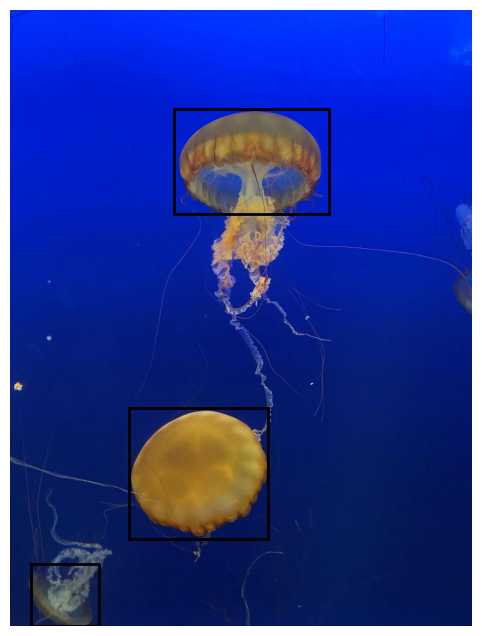

In [21]:
boxes = preds["boxes"].cpu()
scores = preds["scores"].cpu()

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")

for box, score in zip(boxes, scores):
    if score > 0.5:
        x1,y1,x2,y2 = box
        plt.gca().add_patch(
            plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=2)
        )

plt.show()

In [22]:
with torch.no_grad():
    pred = model(img_tensor)[0]

print("Top 10 scores:")
print(pred["scores"][:10])

Top 10 scores:
tensor([0.9904, 0.9511, 0.8077, 0.3435, 0.3387, 0.0953, 0.0557],
       device='cuda:0')
